<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/03_machine_learning/scikit-learn/ensemble-methods/bagging.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/03_machine_learning/scikit-learn/ensemble-methods/bagging.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Ensemble Methods: Bagging (Bootstrap Aggregating)

## Context
In observability, models can easily overfit to noise. For instance, a single decision tree trained to predict if a server will run out of memory might perfectly memorize past traffic spikes but fail entirely in production.

**Bagging (Bootstrap Aggregating)** solves this by:
1. Creating multiple subsets of the original data (Bootstrapping).
2. Training a weak model (like a Decision Tree) on each subset.
3. Aggregating their predictions (Voting for classification, Averaging for regression).

The most famous bagging algorithm is the **Random Forest**.

## Objectives
- Synthesize a dataset for predicting if a server will trigger an OOM (Out of Memory) alert.
- Train a standard `DecisionTreeClassifier` and observe its variance/overfitting.
- Train a `RandomForestClassifier` (a Bagging ensemble) and compare its stability.

## Expected Outcome
- A single decision tree that memorizes the training set (~100% training accuracy) but loses noticeable accuracy on the test set.
- Random Forest and generic Bagging models that narrow that train-test gap, generalizing more reliably than the single tree.
- A visual comparison of train vs. test accuracy across all three models, making the shrinking generalization gap easy to see at a glance.</cell id="8b858e86">


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### 1. Generating Infrastructure Telemetry
We will predict `OOM_Alert` (0=Healthy, 1=Out of Memory) based on `CPU_Usage`, `Memory_Usage`, and `Concurrent_Connections`.

In [2]:
np.random.seed(42)
n_samples = 500

X = pd.DataFrame({
    'CPU_Usage': np.random.normal(60, 20, n_samples),
    'Memory_Usage': np.random.normal(70, 15, n_samples),
    'Concurrent_Connections': np.random.normal(1500, 500, n_samples)
})

# If Memory > 85 and Connections > 1800, high chance of OOM
y = ((X['Memory_Usage'] > 85) & (X['Concurrent_Connections'] > 1800)).astype(int)

# Add some random noise so it isn't a perfect rule
flip_indices = np.random.choice(n_samples, size=30, replace=False)
y[flip_indices] = 1 - y[flip_indices]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2. The Problem with a Single Decision Tree
A single decision tree without depth limits will grow until it perfectly memorizes the training data (overfitting). When it sees the test data, performance drops.

In [3]:
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

print("Single Tree - Training Accuracy: {:.2f}%".format(accuracy_score(y_train, single_tree.predict(X_train))*100))
print("Single Tree - Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, single_tree.predict(X_test))*100))


Single Tree - Training Accuracy: 100.00%
Single Tree - Testing Accuracy: 86.00%


### 3. Random Forest (Bagged Decision Trees)
Random Forest builds many decision trees (e.g., 100). 
Each tree trains on a random sample of the rows AND a random sample of the columns. Individual trees can still fit their own bootstrap sample almost perfectly — training accuracy stays just as high as the single tree's. What changes is that each tree memorizes *different* noise, so the majority vote across 100 trees cancels most of that noise out. The win isn't less training-set memorization; it's a smaller **generalization gap** (training accuracy minus test accuracy), which is what actually matters once the model is serving production traffic.

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest - Training Accuracy: {:.2f}%".format(accuracy_score(y_train, rf_model.predict(X_train))*100))
print("Random Forest - Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, rf_model.predict(X_test))*100))

# Notice how the Testing Accuracy improves! The Random Forest is much more generalized.

Random Forest - Training Accuracy: 100.00%
Random Forest - Testing Accuracy: 90.67%


### 4. Generic Bagging Classifier
You don't have to just bag Decision Trees. You can bag any model (Support Vector Machines, KNN). Scikit-learn provides a wrapper `BaggingClassifier` for this.

In [5]:
# Here we explicitly bag 50 decision trees
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)

print("Generic Bagging - Training Accuracy: {:.2f}%".format(accuracy_score(y_train, bagging_model.predict(X_train))*100))
print("Generic Bagging - Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, bagging_model.predict(X_test))*100))

Generic Bagging - Training Accuracy: 100.00%
Generic Bagging - Testing Accuracy: 90.00%


### 5. Visualizing the Generalization Gap
The printed numbers above are easy to skim past. Plotting train vs. test accuracy side-by-side makes the actual story obvious: all three models fit the training data about equally well, but the gap to test accuracy shrinks a lot once bagging is introduced.

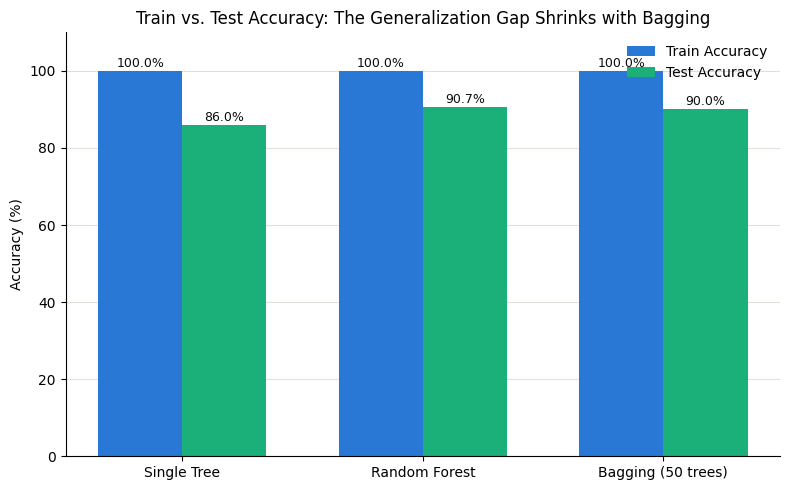

In [6]:
model_names = ['Single Tree', 'Random Forest', 'Bagging (50 trees)']

train_accuracies = [
    accuracy_score(y_train, single_tree.predict(X_train)) * 100,
    accuracy_score(y_train, rf_model.predict(X_train)) * 100,
    accuracy_score(y_train, bagging_model.predict(X_train)) * 100,
]
test_accuracies = [
    accuracy_score(y_test, single_tree.predict(X_test)) * 100,
    accuracy_score(y_test, rf_model.predict(X_test)) * 100,
    accuracy_score(y_test, bagging_model.predict(X_test)) * 100,
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
train_bars = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='#2a78d6')
test_bars = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='#1baf7a')

for bars in (train_bars, test_bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color='#0b0b0b')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Train vs. Test Accuracy: The Generalization Gap Shrinks with Bagging')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 110)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Summary
- **Pros of Bagging:** Massively reduces overfitting, making models highly robust to noise in telemetry data. Works "out-of-the-box" very well.
- **Cons of Bagging:** Harder to interpret than a single decision tree (you can't easily visualize a forest of 100 trees), and takes more compute power to train.